In [64]:

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

### 1. Train Dataset

In [13]:
train = pd.read_csv('data/raw/MELD-RAW/MELD.Raw/train_sent_emo.csv')
val = pd.read_csv('data/raw/MELD-RAW/MELD.Raw/dev_sent_emo.csv')
test = pd.read_csv('data/raw/MELD-RAW/MELD.Raw/test_sent_emo.csv')

print("train, val(dev), test csv files loaded.")

train, val(dev), test csv files loaded.


In [15]:
print("--- first five samples of train ---")
train.head()

--- first five samples of train ---


,Sr No.,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime
0,1,also I was the point person on my companys tr...,Chandler,neutral,neutral,0,0,8,21,"00:16:16,059","00:16:21,731"
1,2,You mustve had your hands full.,The Interviewer,neutral,neutral,0,1,8,21,"00:16:21,940","00:16:23,442"
2,3,That I did. That I did.,Chandler,neutral,neutral,0,2,8,21,"00:16:23,442","00:16:26,389"
3,4,So lets talk a little bit about your duties.,The Interviewer,neutral,neutral,0,3,8,21,"00:16:26,820","00:16:29,572"
4,5,My duties? All right.,Chandler,surprise,positive,0,4,8,21,"00:16:34,452","00:16:40,917"


In [16]:
print("--- first five samples of val/dev ---")
val.head()

--- first five samples of val/dev ---


,Sr No.,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime
0,1,"Oh my God, hes lost it. Hes totally lost it.",Phoebe,sadness,negative,0,0,4,7,"00:20:57,256","00:21:00,049"
1,2,What?,Monica,surprise,negative,0,1,4,7,"00:21:01,927","00:21:03,261"
2,3,"Or! Or, we could go to the bank, close our acc...",Ross,neutral,neutral,1,0,4,4,"00:12:24,660","00:12:30,915"
3,4,Youre a genius!,Chandler,joy,positive,1,1,4,4,"00:12:32,334","00:12:33,960"
4,5,"Aww, man, now we wont be bank buddies!",Joey,sadness,negative,1,2,4,4,"00:12:34,211","00:12:37,505"


In [19]:
print("--- first five samples of test ---")
test.head()

--- first five samples of test ---


,Sr No.,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime
0,1,Why do all youre coffee mugs have numbers on ...,Mark,surprise,positive,0,0,3,19,"00:14:38,127","00:14:40,378"
1,2,Oh. Thats so Monica can keep track. That way ...,Rachel,anger,negative,0,1,3,19,"00:14:40,629","00:14:47,385"
2,3,Y'know what?,Rachel,neutral,neutral,0,2,3,19,"00:14:56,353","00:14:57,520"
3,19,"Come on, Lydia, you can do it.",Joey,neutral,neutral,1,0,1,23,"0:10:44,769","0:10:46,146"
4,20,Push!,Joey,joy,positive,1,1,1,23,"0:10:46,146","0:10:46,833"


In [23]:
shape = pd.DataFrame({
    'train': train.shape,
    'val/dev': val.shape,
    'test': test.shape
})
print("shapes of each dataset:")
shape

shapes of each dataset:


,train,val/dev,test
0,9989,1109,2610
1,11,11,11


In [25]:
utterances = pd.Series({
    'train': train.shape[0],
    'val/dev': val.shape[0],
    'test': test.shape[0]
})
print("number of utterances in each dataset:")
utterances

number of utterances in each dataset:


train      9989
val/dev    1109
test       2610
dtype: int64

In [42]:
print("number of unique speakers in train: ", len(train['Speaker'].unique()))
print("unique speakers: ", list(train['Speaker'].unique()))
print()

print("number of unique speakers in val/dev: ", len(val['Speaker'].unique()))
print("unique speakers: ", list(val['Speaker'].unique()))
print()

print("number of unique speakers in test: ", len(test['Speaker'].unique()))
print("unique speakers: ", list(test['Speaker'].unique()))


number of unique speakers in train:  260
unique speakers:  ['Chandler', 'The Interviewer', 'Joey', 'Rachel', 'Monica', 'Phoebe', 'Ross', 'Sergei', 'Customer', 'Jade', 'Mona', 'Charlie', 'Paleontologist', 'Professore Clerk', 'Caitlin', 'Nurse', 'Mr. Treeger', 'Carol', 'The Casting Director', 'Emily', 'Elizabeth', 'Paul', 'The Dry Cleaner', 'Joey and Chandler', 'Kate', 'The Director', 'Mr. Tribbiani', 'Guru Saj', 'Wayne', 'Richard', 'Dina', 'Bobby', 'Danny', 'Krista', 'Jill', 'Doug', 'Stevens', 'Bob', 'Mr. Franklin', 'Director', 'Janice', 'Tony', 'Peter', 'Ticket Counter Attendant', 'Dr. Long', 'Charlton Heston', 'Joshua', 'Nancy', 'Kim', 'Joanna', 'Cassie', 'Dr. Rhodes', 'Dr. Johnson', 'Kristen', 'Jester', 'Sarah', 'Pete', 'The Singing Man', 'Commercial', 'Mark', 'A Female Student', 'All', 'Cliff', 'Tag', 'Eric', 'Dr. Green', 'Mr. Heckles', 'Mr. Geller', 'Sophie', 'Singer', 'David', 'Hitchhiker', '1st Customer', '2nd Customer', '3rd Customer', 'The Presenter', 'Policeman', 'Duncan', 'Ja

In [45]:
train_set = set(train['Speaker'])
val_set = set(val['Speaker'])
test_set = set(test['Speaker'])

all3 = train_set & val_set & test_set
print("number of common speakers in all three datasets: ", len(all3))
print("common speakers in all three datasets: ", all3)
print()

train_val = train_set & val_set
print("number of common speakers in train & val datasets: ", len(train_val))
print("common speakers in train & val datasets: ", train_val)
print()

train_test = train_set & test_set
print("number of common speakers in train & test datasets: ", len(train_test))
print("common speakers in train & test datasets: ", train_test)
print()

val_test = val_set & test_set
print("number of common speakers in val & test datasets: ", len(val_test))
print("common speakers in val & test datasets: ", val_test)

number of common speakers in all three datasets:  21
common speakers in all three datasets:  {'Tag', 'Mrs. Geller', 'Phoebe', 'Frank', 'Chandler', 'Gary', 'Elizabeth', 'Monica', 'Ross', 'The Dry Cleaner', 'Guy', 'Carol', 'Rachel', 'Susan', 'Bob', 'Joey', 'Joanna', 'Woman', 'Mark', 'Cliff', 'All'}

number of common speakers in train & val datasets:  33
common speakers in train & val datasets:  {'Tag', 'Mrs. Geller', 'Carl', 'Kyle', 'Mrs. Green', 'Charlie', 'Estelle', 'Alice', 'Phoebe', 'Frank', 'Chandler', 'Gary', 'Janine', 'Elizabeth', 'Monica', 'Ross', 'The Dry Cleaner', 'Guy', 'Carol', 'Rachel', 'Kate', 'Susan', 'Bob', 'Dr. Long', 'Joey', 'Joanna', 'Ursula', 'Woman', 'Doctor', 'Mark', 'Cliff', 'All', 'Jeannine'}

number of common speakers in train & test datasets:  69
common speakers in train & test datasets:  {'Janice', 'Tag', 'Tour Guide', 'Mrs. Geller', 'Chloe', 'The Instructor', 'Director', 'Lorraine', 'Dana', 'Dina', 'Sarah', 'Chip', 'Lydia', 'Phoebe Sr', 'Gunther', 'The Directo

In [ ]:
print("number of utterances per speaker (sorted): ", )

no_utterances = pd.DataFrame({
    'train': dict(Counter(train['Speaker']).most_common()),
    'val': dict(Counter(val['Speaker']).most_common()),
    'test': dict(Counter(test['Speaker']).most_common())
}).fillna(0)

no_utterances.head(10)

number of utterances per speaker (sorted): 


,train,val,test
Joey,1509.0,149.0,411.0
Ross,1459.0,217.0,373.0
Rachel,1435.0,164.0,356.0
Phoebe,1321.0,185.0,291.0
Monica,1299.0,137.0,346.0
Chandler,1283.0,101.0,379.0
Janice,58.0,0.0,31.0
Carol,46.0,13.0,1.0
Emily,43.0,0.0,16.0
Tag,41.0,7.0,12.0


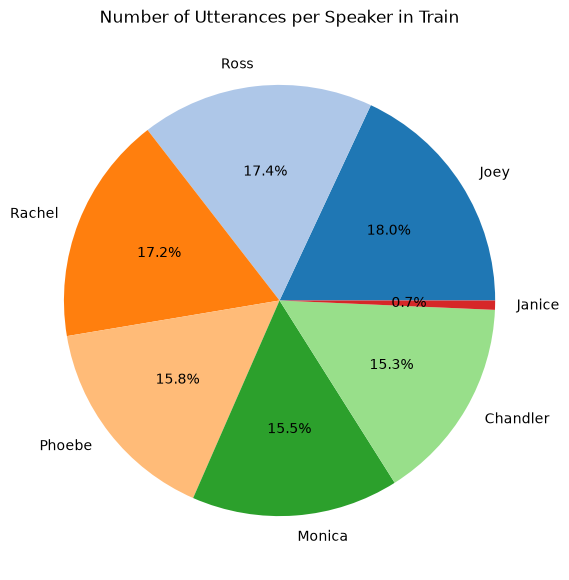

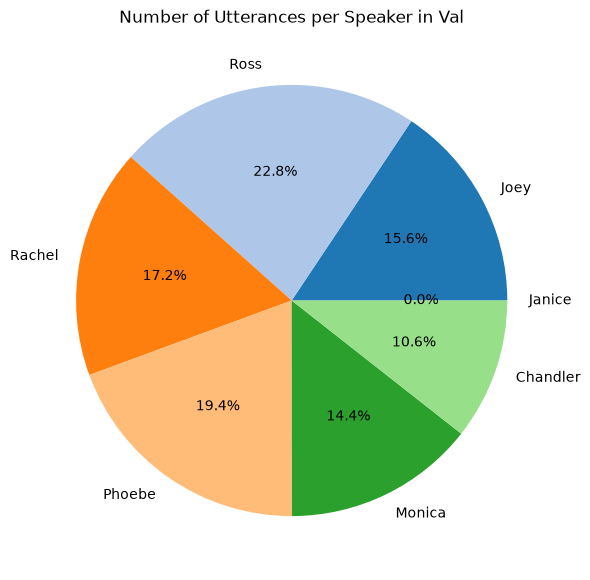

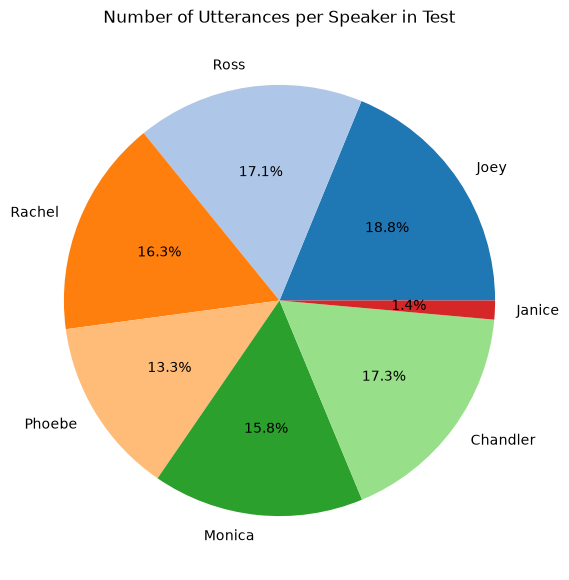

In [96]:
for i in ['train', 'val', 'test']:
    data = no_utterances[i].head(7)
    colors = plt.cm.tab20.colors[: len(no_utterances[i])]
    plt.figure(figsize=(7, 7))
    plt.pie(
        data,
        labels=data.index,
        autopct="%1.1f%%",
        startangle=0,
        colors=colors,
    )

    plt.title(f"Number of Utterances per Speaker in {i.capitalize()}")
    plt.show()


NOTE: Ross has higher samples in the 'val' set than Joey, but is ranked lower as Joey has higher train samples. (internal adjustment by python)

NOTE to self: split == train = phoebe, monica, chandler, janice. val == rachel, ross. test == joey

In [97]:
print("emotion distribution: ")

train_emo = dict(Counter(train['Emotion']).most_common())
val_emo = dict(Counter(val['Emotion']).most_common())
test_emo = dict(Counter(test['Emotion']).most_common())

emo_distb = pd.DataFrame({
    'train': train_emo,
    'val': val_emo,
    'test': test_emo
})

emo_distb

emotion distribution: 


,train,val,test
neutral,4710,470,1256
joy,1743,163,402
surprise,1205,150,281
anger,1109,153,345
sadness,683,111,208
disgust,271,22,68
fear,268,40,50


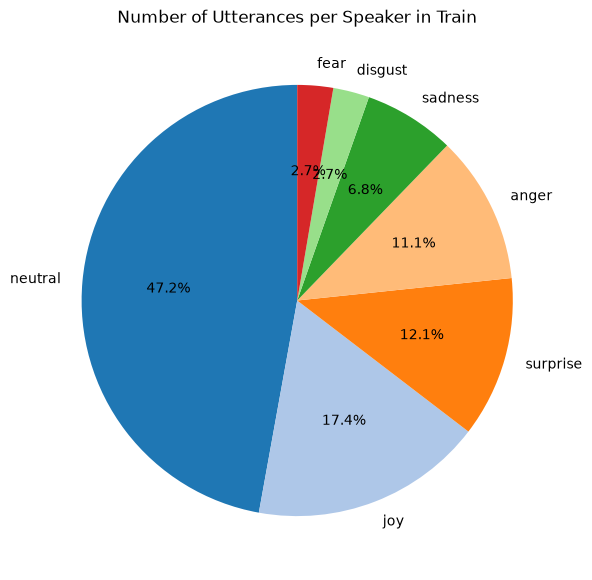

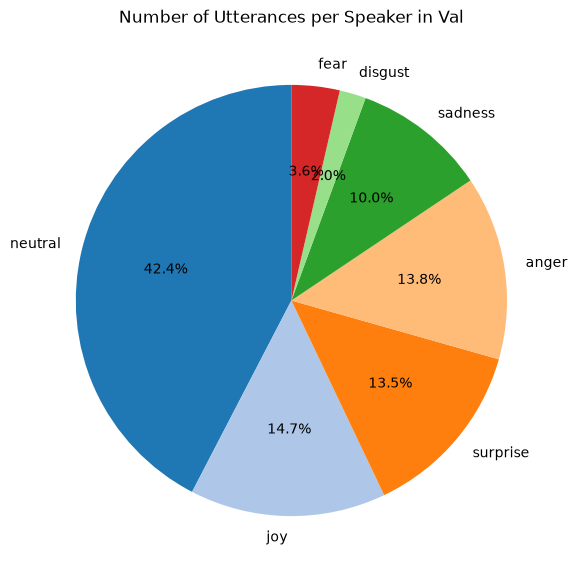

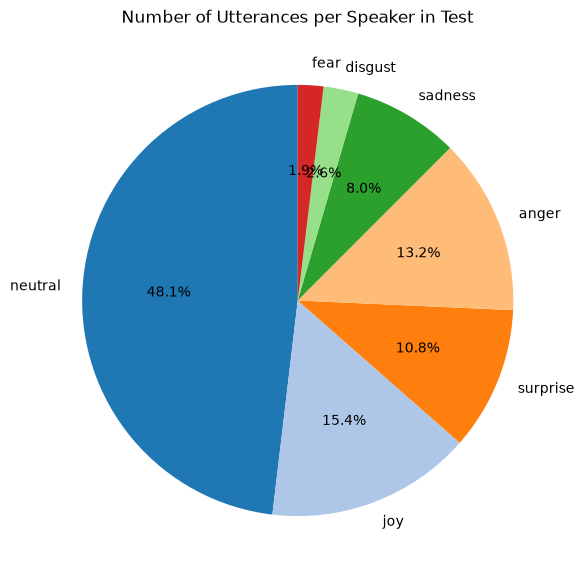

In [98]:
for i in ['train', 'val', 'test']:
    data = emo_distb[i]
    colors = plt.cm.tab20.colors[: len(emo_distb[i])]
    plt.figure(figsize=(7, 7))
    plt.pie(
        data,
        labels=data.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
    )

    plt.title(f"Number of Utterances per Speaker in {i.capitalize()}")
    plt.show()


In [99]:
print("emotion distribution per speaker: ")

print(train_emo)

emotion distribution per speaker: 
{'neutral': 4710, 'joy': 1743, 'surprise': 1205, 'anger': 1109, 'sadness': 683, 'disgust': 271, 'fear': 268}


NEED: 'joey': {'neutral': x, 'joy': y...}